## 1. Incarcare date

Dataset: Student Dropout Prediction

Dimensiuni initiale: 10000 inregistrari, 20 de coloane

Target: Dropout (0 = nu a abandonat, 1 = a abandonat)

In [1]:
import pandas as pd
import numpy as np
import copy as deepcopy

In [2]:
df = pd.read_csv('../dataset/student_dropout_dataset_v3.csv')
df.head(10)

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout,Unnamed: 19
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0,NaN
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1,NaN
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0,
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1,NaN
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0,NaN
5,6,20.5,Male,25000.0,Yes,4.11,89.1,2,47.1,No,Yes,6.0,2.52,2.72,2.69,Year 3,Business,NaN,0,NaN
6,7,24.5,Male,25000.0,Yes,3.00,78.2,1,37.4,Yes,Yes,7.3,0.64,0.33,0.44,Year 4,CS,Bachelor,0,NaN
7,8,22.7,Female,25000.0,Yes,2.12,86.4,1,34.0,No,Yes,6.5,1.79,1.14,1.14,Year 1,Arts,High School,0,NaN
8,9,20.0,Male,57413.0,Yes,4.07,97.5,3,52.1,No,No,4.2,3.08,2.81,2.81,Year 1,CS,High School,0,NaN
9,10,22.2,Female,44930.0,Yes,2.98,82.2,1,19.7,No,No,6.7,1.59,1.73,1.73,Year 1,Science,Master,0,NaN


## 2. EDA

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  str    
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  str    
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  str    
 10  Scholarship            10000 non-null  str    
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Semester      

Observatii importante: 20 de coloane din care 9 numerice, 3 intregi, 8 text

Coloane cu valori lipsa: 

    Family_Income - 500 lipsa (5%)

    Study_Hours_per_Day - 500 lipsa (5%)

    Stress_Index - 500 lipsa (5%)

    Parental_Education - 511 lipsa (5.1%)

    Unnamed: 19 - coloana goala, va fi stearsa

In [4]:
df.dtypes

Student_ID                 int64
Age                      float64
Gender                       str
Family_Income            float64
Internet_Access              str
Study_Hours_per_Day      float64
Attendance_Rate          float64
Assignment_Delay_Days      int64
Travel_Time_Minutes      float64
Part_Time_Job                str
Scholarship                  str
Stress_Index             float64
GPA                      float64
Semester_GPA             float64
CGPA                     float64
Semester                     str
Department                   str
Parental_Education           str
Dropout                    int64
Unnamed: 19                  str
dtype: object

In [5]:
df.describe()

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761,0.23540
std,2886.89568,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555,0.42427
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000,0.00000
50%,5000.50000,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,7500.25000,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000,0.00000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


- Age: intre 17 si 29.6 ani, medie 21 - varste tipice studentesti

- Family_Income: medie 38377, max 316601 - distributie asimetrica

- GPA: valori intre 0 si 4 - scala standard americana

- Dropout: medie 0.235, deci rata de abandon: 24%

In [6]:
df.describe(include='object')

C:\Users\libot\AppData\Local\Temp\ipykernel_5932\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Gender,Internet_Access,Part_Time_Job,Scholarship,Semester,Department,Parental_Education,Unnamed: 19
count,10000,10000,10000,10000,10000,10000,9489,1
unique,2,2,2,2,4,5,4,1
top,Female,Yes,No,No,Year 4,Science,Bachelor,
freq,5011,8769,5996,6489,2536,2061,3949,1


Observatii: 

- Gender: usor mai multe femei, 50,1%

- Internet_Acess: 87,7% au acces la internet

- Part_Time_Job: 40% au job part-time

- Scholarship: 35,1% au bursa

- Semester: 4 ani universitari, Year 4 cel mai frecvent

- Department: 5 departamente, Science e cel mai mare

- Parental_Education: 4 niveluri, Bachelor dominant 40%

In [7]:
df['Dropout'].value_counts(normalize=True)

Dropout
0    0.7646
1    0.2354
Name: proportion, dtype: float64

Dropout: 76% non-dropout (0) vs 24% dropout (1)

Dataset usor dezechilibrat, deci un model care prezice mereu 0 ar avea 76% acuratete fara sa invete nimic util. Va trebui sa tinem cont de acest dezechilibru la evaluarea modelului.

In [8]:
df.corr(numeric_only=True)['Dropout'].sort_values() 

GPA                     -0.460352
Semester_GPA            -0.445396
CGPA                    -0.444807
Attendance_Rate         -0.163539
Study_Hours_per_Day     -0.089376
Family_Income           -0.011123
Student_ID               0.007434
Age                      0.007585
Travel_Time_Minutes      0.028080
Assignment_Delay_Days    0.082327
Stress_Index             0.255648
Dropout                  1.000000
Name: Dropout, dtype: float64

Corelatii intre fiecare variabila numerica si Dropout

Valori intre -1 si 1. Top predictori:
    GPA -0,46 -> GPA mai mare = risc mai mic de abandon

    Semester_GPA -0,45 -> similar cu GPA (sunt corelate intre ele)

    CGPA -0,44 -> similar cu GPA (sunt corelate intre ele)

    Stress_Intex +0,26 -> stres mai mare = rist mai mare de abandon
    
    Attendance_Rate -0.16 -> prezenta mai mare = risc mai mic

Variabile cu corelatie slaba:
    Age, Family_Income, Travel_Time_Minutes (posibil irelevante)

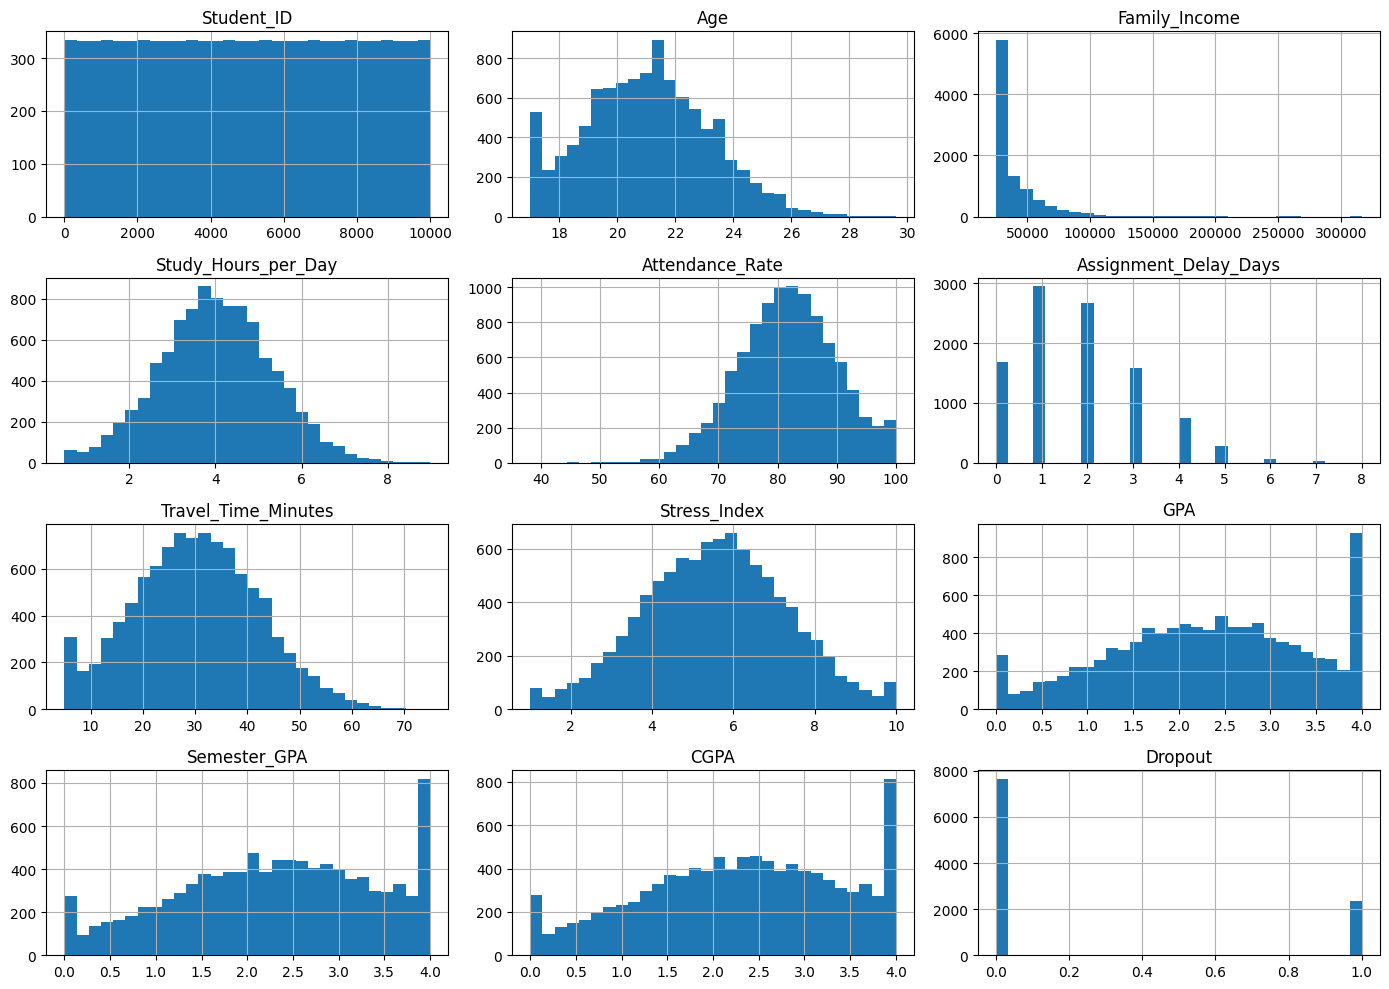

In [9]:
import matplotlib.pyplot as plt
df.hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

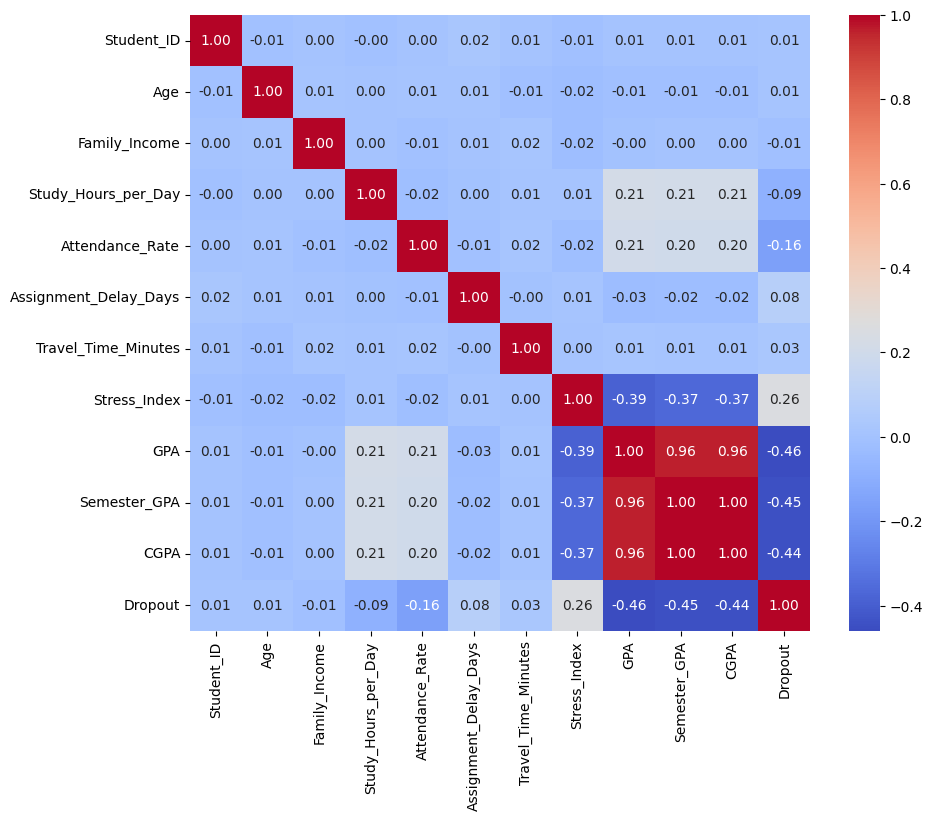

In [10]:
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

Vizualizarea corelatiilor intre toate variabilele numerice

Observatii:

- GPA, Semeste_GPA si CGPA sunt corelate intre ele, deci contin practic aceeasi informatie, prin urmare vom pastra doar GPA si vom elimina Semeter_GPA, si CGPA

### Distributie dropout (0 = nu a abandonat, 1 = a abandonat)

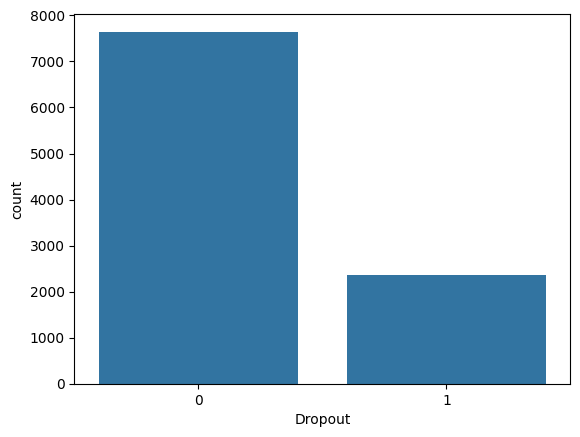

In [11]:
sns.countplot(x='Dropout', data=df)
plt.show()

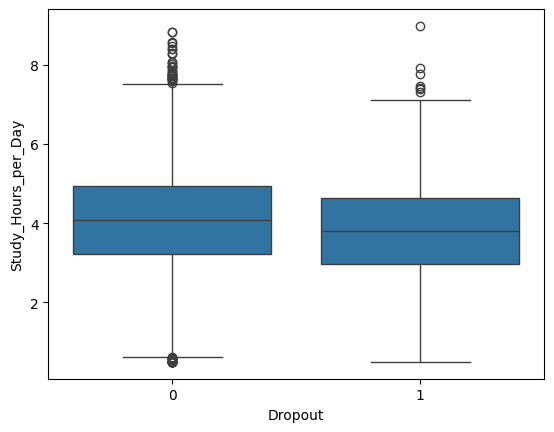

In [12]:
sns.boxplot(x='Dropout', y='Study_Hours_per_Day', data=df)
plt.show()

Observatii:

- Studentii care nu abandoneaza au in medie mai multe ore de studiu decat cei care abandoneaza.


In [13]:
Q1 = df['Study_Hours_per_Day'].quantile(0.25)
Q3 = df['Study_Hours_per_Day'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['Study_Hours_per_Day'] < Q1 - 1.5*IQR) | 
              (df['Study_Hours_per_Day'] > Q3 + 1.5*IQR)]

In [14]:
outliers[['Study_Hours_per_Day', 'Dropout']]

,Study_Hours_per_Day,Dropout
41,7.60,0
219,0.50,0
229,8.47,0
446,0.50,0
807,8.41,0
...,...,...
9067,0.50,1
9627,0.50,1
9840,0.50,0
9912,8.28,0


Toti outlierii cu valorile lor si status dropout.

In [15]:
total = len(df)
num_outliers = len(outliers)
print(f"{num_outliers/total*100:.2f}% outliers in Study_Hours_per_Day")

0.86% outliers in Study_Hours_per_Day


Rezultat: 86 de outlieri = 0.86% din dataset

Decizie: Ii pastram deoarece:

- Procentul este de sub 5%, adica are un impact redus asupra modelului

- Dupa cum am vazut anterior, valorile sun plauzibile (0.5h si ~8-9h/zi)

- Valorile extreme pot sa fie un semnal important pentru predictie

<Axes: xlabel='Stress_Index', ylabel='Density'>

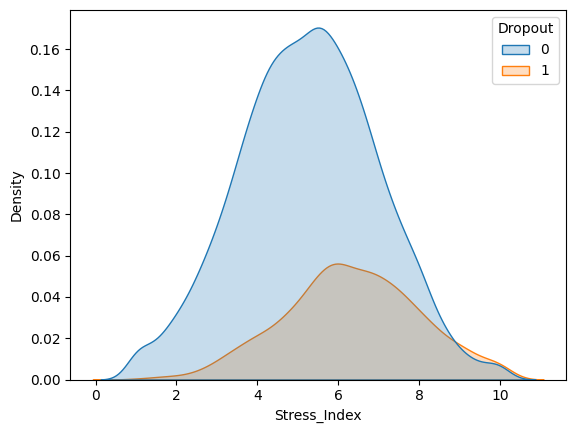

In [16]:
sns.kdeplot(data=df, x='Stress_Index', hue='Dropout', fill=True)

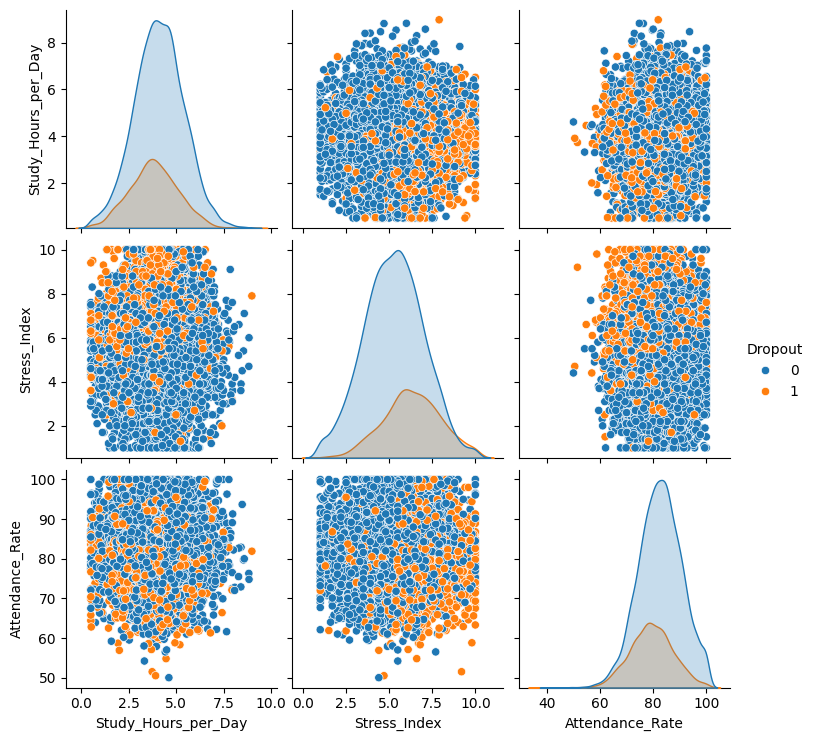

In [17]:
sns.pairplot(df[['Study_Hours_per_Day', 'Stress_Index', 'Attendance_Rate', 'Dropout']], hue='Dropout')

Observatii:

- Studentii dropout tind sa aiba GPA mai mic, stres mai mare si prezenta mai mica

## 3. Curatarea datelor

### Eliminam coloane inutile

- Student_ID - identificator unic, fara valoare predictiva

- Unamed: 19 - coloana goala

- Semester_GPA si CGPA - corelate puternic cu GPA, informatie redundanta

In [18]:
df = df.drop(columns=['Student_ID', 'Unnamed: 19', 'Semester_GPA', 'CGPA'])

### Tratam NaN-urile

Family_Income, Study_Hours_per_Day, Stress_Index (5% fiecare):

    - folosim mediana in loc de medie deoarece distributiile sunt asimetrice

Parental_Education (5,1%): 

    - categorie noua 'Unknown' in loc de most_frequent pentru ca lipsa acestei informatii poate sa fie un semnal in sine

In [19]:
df['Family_Income'] = df['Family_Income'].fillna(df['Family_Income'].median())
df['Study_Hours_per_Day'] = df['Study_Hours_per_Day'].fillna(df['Study_Hours_per_Day'].median())
df['Stress_Index'] = df['Stress_Index'].fillna(df['Stress_Index'].median())
df['Parental_Education'] = df['Parental_Education'].fillna('Unknown')# Parental_Education: 511 NaN (5,1%) - imputare cu 'Unknown' in loc de most_frequent 
# pentru ca lipsa datelor poate fi semnificativa pentru predictia dropout-ului

### Binary encoding

Transformam coloanele Yes/No si Male/Female in valori 0/1

In [20]:
binary_cols = {
    'Gender': ('is_female', {'Male': 0, 'Female': 1}),
    'Internet_Access': ('has_internet_access', {'Yes': 1, 'No': 0}),
    'Part_Time_Job': ('has_part_time_job', {'Yes': 1, 'No': 0}),
    'Scholarship': ('has_scholarship', {'Yes': 1, 'No': 0})
}

for old_name, (new_name, mapping) in binary_cols.items():
    df[new_name] = df[old_name].map(mapping)
    df = df.drop(columns=[old_name])

In [21]:
df[['is_female', 'has_internet_access', 'has_part_time_job', 'has_scholarship']].head(10)

,is_female,has_internet_access,has_part_time_job,has_scholarship
0,0,1,1,0
1,0,1,0,0
2,0,1,1,0
3,0,1,0,0
4,1,1,0,0
5,0,1,0,1
6,0,1,1,1
7,1,1,0,1
8,0,1,0,0
9,1,1,0,0


### Ordinal encoding

Semester are ordine naturala, adica Year 1 < Year 2 < Year 3 < Year 4

Asadar, pastra informatia ca Year 4 e mai avansat decat Year 1

In [22]:
df['Semester'] = df['Semester'].map({'Year 1': 0, 'Year 2': 1, 'Year 3': 2, 'Year 4': 3})
print(df)

       Age  Family_Income  Study_Hours_per_Day  Attendance_Rate  \
0     22.1        25000.0                 3.36             86.1   
1     20.7        25000.0                 4.30             68.0   
2     22.4        40183.0                 4.40             70.9   
3     24.4        29740.5                 4.00             82.2   
4     20.5        25319.0                 4.19             75.7   
...    ...            ...                  ...              ...   
9995  23.9        42286.0                 4.62             92.0   
9996  17.0        61103.0                 2.87             75.2   
9997  19.4        25000.0                 4.73             74.9   
9998  22.1        40302.0                 5.85             74.2   
9999  22.4        76796.0                 4.95             83.7   

      Assignment_Delay_Days  Travel_Time_Minutes  Stress_Index   GPA  \
0                         2                 20.4           5.5  0.96   
1                         2                 44.0   

### One-Hot Encoding



In [23]:
df = pd.get_dummies(df, columns=['Department', 'Parental_Education'], drop_first=True, dtype=int)


In [24]:
df.isnull().sum()


Age                               0
Family_Income                     0
Study_Hours_per_Day               0
Attendance_Rate                   0
Assignment_Delay_Days             0
Travel_Time_Minutes               0
Stress_Index                      0
GPA                               0
Semester                          0
Dropout                           0
is_female                         0
has_internet_access               0
has_part_time_job                 0
has_scholarship                   0
Department_Business               0
Department_CS                     0
Department_Engineering            0
Department_Science                0
Parental_Education_High School    0
Parental_Education_Master         0
Parental_Education_PhD            0
Parental_Education_Unknown        0
dtype: int64

Verificarea finala confirma ca nu mai exista valori lipsa si ca toate sunt numerice

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             10000 non-null  float64
 1   Family_Income                   10000 non-null  float64
 2   Study_Hours_per_Day             10000 non-null  float64
 3   Attendance_Rate                 10000 non-null  float64
 4   Assignment_Delay_Days           10000 non-null  int64  
 5   Travel_Time_Minutes             10000 non-null  float64
 6   Stress_Index                    10000 non-null  float64
 7   GPA                             10000 non-null  float64
 8   Semester                        10000 non-null  int64  
 9   Dropout                         10000 non-null  int64  
 10  is_female                       10000 non-null  int64  
 11  has_internet_access             10000 non-null  int64  
 12  has_part_time_job               10000 non-nu

### Corelatii dupa Encoding

Afisam doar corelatiile mai mari de 0,1 pentru a nu aglomera si pentru a putea observa mai bine ce variabile au corelatie mai puternica cu variabila tinta, Dropout

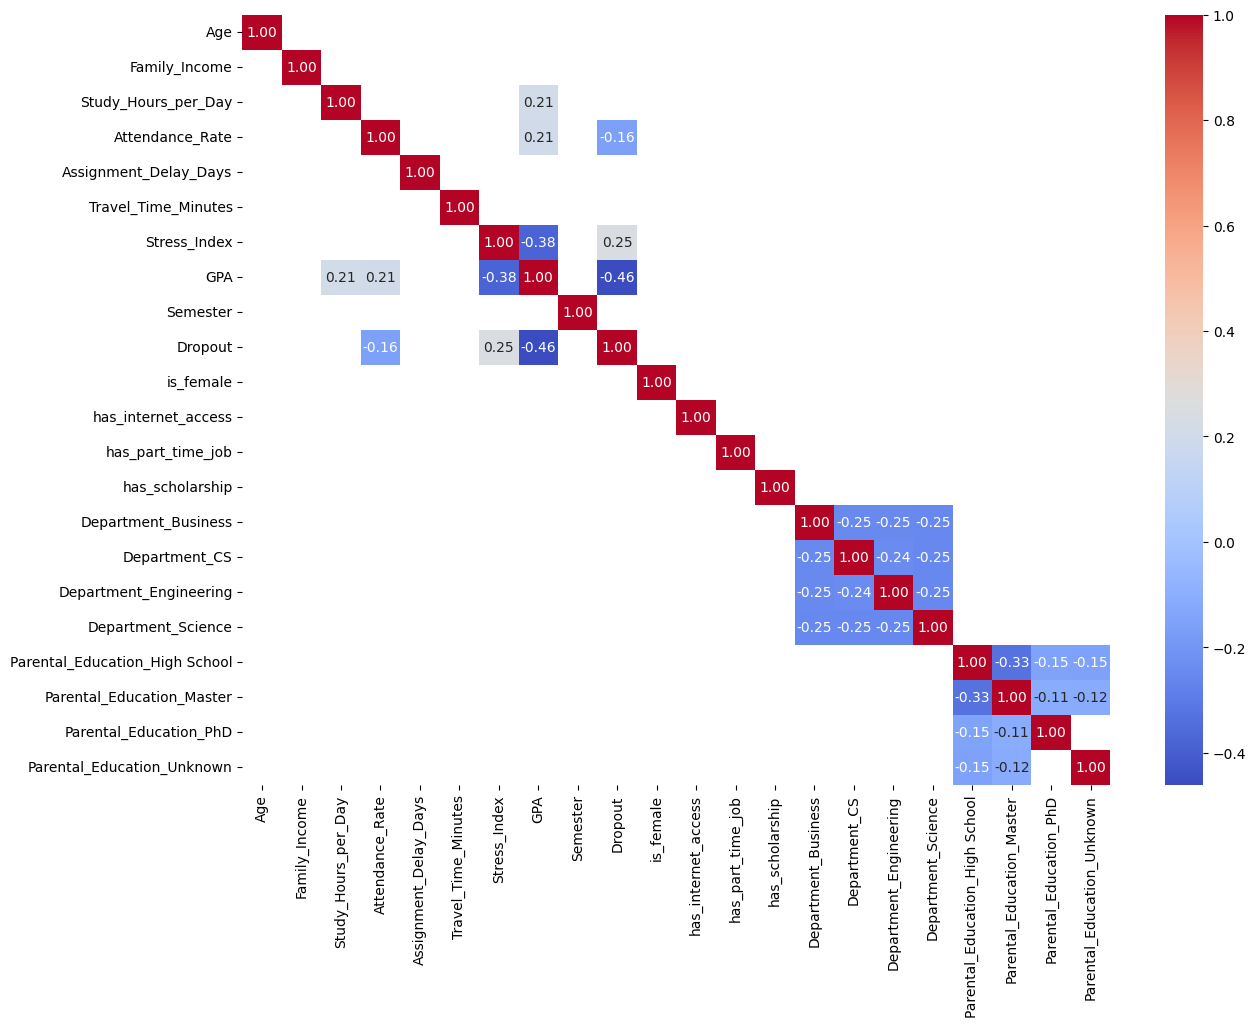

In [26]:
corr = df.corr()
treshold = 0.1
mask = np.abs(corr) <=treshold
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f',mask=mask, cmap='coolwarm')
plt.show()

In [27]:
df.to_csv('../dataset/student_dropout_dataset_v4.csv', index=False)
print(f"Salvat! Dimensiuni finale: {df.shape}")

Salvat! Dimensiuni finale: (10000, 22)


## 4. FEATURE ENGINEERING

### 4.1 study_efficiency = GPA / Study_Hours_per_Day

Masoara cat de eficient este un student:

- GPA mare cu putine ore inseamna o eficienta ridicata

- GPA mai mic cu multe ore inseamna o eficienta scazuta

Prin urmare, eficienta scazuta ar putea indica riscul de abandon

In [28]:
df['study_efficiency'] = df['GPA'] / df['Study_Hours_per_Day']

print("=== study_efficiency ===")
print(df['study_efficiency'].describe())
print(f"Corelatie cu Dropout: {df['study_efficiency'].corr(df['Dropout']):.4f}")

=== study_efficiency ===
count    10000.000000
mean         0.639005
std          0.442509
min          0.000000
25%          0.384000
50%          0.583492
75%          0.802947
max          8.000000
Name: study_efficiency, dtype: float64
Corelatie cu Dropout: -0.2858


In [29]:
# Verificam valorile extreme ale study_efficiency
print("=== Top 5 cele mai mari valori ===")
print(df[['GPA', 'Study_Hours_per_Day', 'study_efficiency', 'Dropout']]
      .sort_values('study_efficiency', ascending=False)
      .head())

print("\n=== Top 5 cele mai mici valori ===")
print(df[['GPA', 'Study_Hours_per_Day', 'study_efficiency', 'Dropout']]
      .sort_values('study_efficiency')
      .head())

=== Top 5 cele mai mari valori ===
       GPA  Study_Hours_per_Day  study_efficiency  Dropout
6179  4.00                 0.50          8.000000        0
5860  4.00                 0.54          7.407407        0
3320  3.49                 0.50          6.980000        0
6676  3.36                 0.50          6.720000        0
4053  4.00                 0.63          6.349206        0

=== Top 5 cele mai mici valori ===
      GPA  Study_Hours_per_Day  study_efficiency  Dropout
9990  0.0                 1.62               0.0        1
4900  0.0                 4.48               0.0        1
4877  0.0                 2.49               0.0        0
1021  0.0                 3.30               0.0        0
2144  0.0                 2.86               0.0        0


study_efficiency cu protectie la valori extreme

Adaugam 0.5 la numitor pentru a evita distorsiunea matematica cauzata de outlierii cu Study_Hours = 0.5h

In [30]:
df['study_efficiency'] = df['GPA'] / (df['Study_Hours_per_Day'] + 0.5)

print(f"Corelatie noua cu Dropout: {df['study_efficiency'].corr(df['Dropout']):.4f}")
print(df['study_efficiency'].describe())

Corelatie noua cu Dropout: -0.3457
count    10000.000000
mean         0.547387
std          0.315346
min          0.000000
25%          0.343252
50%          0.519833
75%          0.705185
max          4.000000
Name: study_efficiency, dtype: float64


### 4.2 is_high_stress = 1 daca Stress_Index > 7 - ANALIZAT, NEADAUGAT

Stresul are corelatie +0.26 cu Dropout dar nu exista un prag dincolo de care devine critic, nu este o relatie liniara

Studentii cu stres ridicat: 18.4%

Rata de dropout per grup:

    Stres normal: 19.7%

    Stres ridicat: 40.5%

Concluzie: Stresul ridicat e un factor de risc major, dar Stress_Index are corelatie mai puternica cu Dropout (+0.26) decat versiunea binara (+0.190). Deci renuntam pentru a evita redundanta.


In [31]:
is_high_stress_temp = (df['Stress_Index'] > 7).astype(int)
print(df.groupby(is_high_stress_temp)['Dropout'].mean())

Stress_Index
0    0.197157
1    0.405111
Name: Dropout, dtype: float64


### 4.3 is_low_attendance = 1 daca Attendance_Rate < 70 - ANALIZAT, NEADAUGAT

Sub 70% prezenta e un semnal de alarma. Verificam daca acest prag captureaza un pattern clar.

Studentii cu prezneta scazuta: 7.5%

Rata dropout per grup:

    Prezenta normala: 22.3%

    Prezenta scazuta: 39.0%

Concluzie: prezenta scazuta e un factor de risc clar dar Attendance_Rate original are o corelatie mai mare cu Dropout (-0.164) decat versiunea binara (-0.104). Deci renuntam pentru a evita redundanta.

In [32]:
is_low_attendance_temp = (df['Attendance_Rate'] < 70).astype(int)
print(df.groupby(is_low_attendance_temp)['Dropout'].mean())

Attendance_Rate
0    0.222835
1    0.390146
Name: Dropout, dtype: float64


### 4.4 risk_score = Stress_Index + Assignment_Delays_Days - Attendance_Rate / 10

Attendance_Rate e impartit la 10 pentru a aduce toate la aceeasi scara (-1, 10)

Rezultat - corelatii cu Dropout:

    Stress_Index: +0.249

    Assignment_Delay_Days: +0.082

    Attendance_Rate: -0.164

    risk_score: +0.286  -> mai bun ca oricare

In [33]:
df['risk_score'] = (df['Stress_Index'] + 
                    df['Assignment_Delay_Days'] - 
                    df['Attendance_Rate'] / 10)

Situatia dupa Feature Engineering

In [34]:
print("Dimensiuni df:", df.shape)
print("\nColoane:")
print(df.columns.tolist())
print(f"\nCorelatie features noi vs Dropout:")
print(f"  study_efficiency: {df['study_efficiency'].corr(df['Dropout']):.4f}")
print(f"  risk_score:       {df['risk_score'].corr(df['Dropout']):.4f}")

Dimensiuni df: (10000, 24)

Coloane:
['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA', 'Semester', 'Dropout', 'is_female', 'has_internet_access', 'has_part_time_job', 'has_scholarship', 'Department_Business', 'Department_CS', 'Department_Engineering', 'Department_Science', 'Parental_Education_High School', 'Parental_Education_Master', 'Parental_Education_PhD', 'Parental_Education_Unknown', 'study_efficiency', 'risk_score']

Corelatie features noi vs Dropout:
  study_efficiency: -0.3457
  risk_score:       0.2863


## 5. FEATURE IMPORTANCE

Folosim Random Forest pentru a masura importanta fiecarui feature

CONCLUZIE: Pastram toate coloanele, s-a dovedit ca cele 2 features adaugate sunt importante.

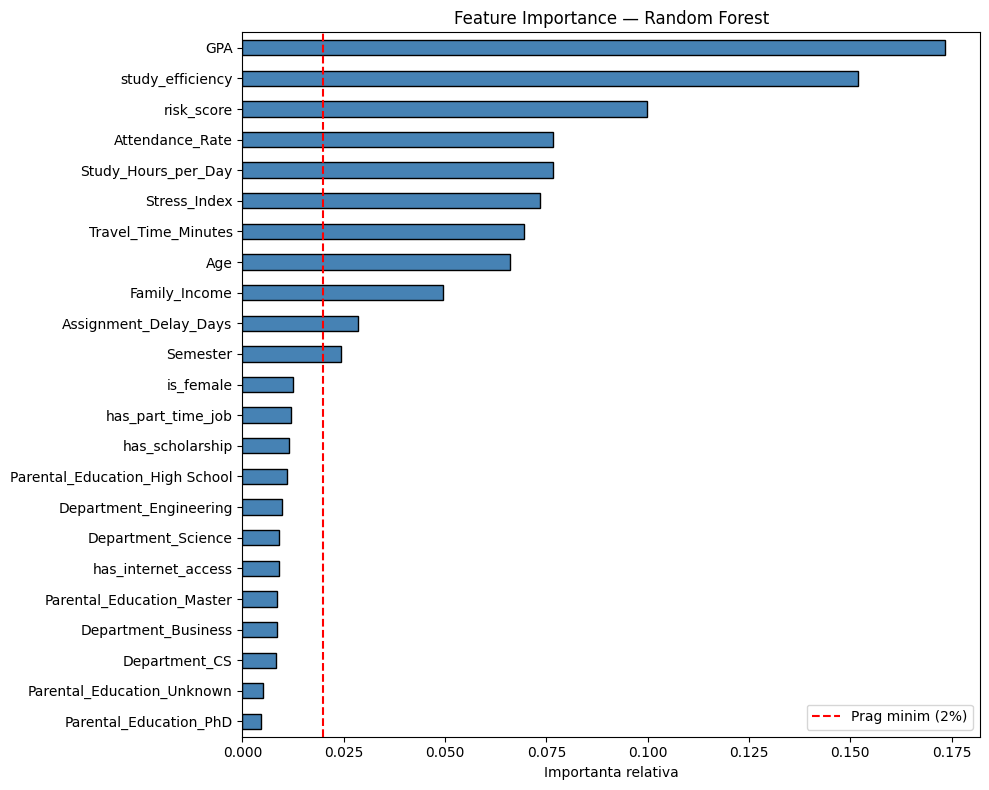

In [35]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns=['Dropout'])
y = df['Dropout']

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importances.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importanta relativa')
plt.axvline(x=0.02, color='red', linestyle='--', label='Prag minim (2%)')
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
df.to_csv('../dataset/student_dropout_dataset_v5.csv', index=False)
print(f"Salvat! Dimensiuni finale: {df.shape}")

Salvat! Dimensiuni finale: (10000, 24)


### Saptamana 8 - antrenare modele

In [37]:
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, RocCurveDisplay
)


In [38]:
df2 = pd.read_csv('../dataset/student_dropout_dataset_v5.csv')
 
print(f'Dimensiuni dataset: {df2.shape}')
print(f'\nDistributia target-ului:')
print(df2['Dropout'].value_counts())
print(f'\nProcente:')
print(df2['Dropout'].value_counts(normalize=True).round(3) * 100)


Dimensiuni dataset: (10000, 24)

Distributia target-ului:
Dropout
0    7646
1    2354
Name: count, dtype: int64

Procente:
Dropout
0    76.5
1    23.5
Name: proportion, dtype: float64


### Separare features si target

In [39]:
X = df2.drop(columns=['Dropout'])
y = df2['Dropout']
 
print(f'\nFeatures (X): {X.shape[1]} coloane, {X.shape[0]} randuri')
print(f'Target (y): {y.shape[0]} valori')



Features (X): 23 coloane, 10000 randuri
Target (y): 10000 valori


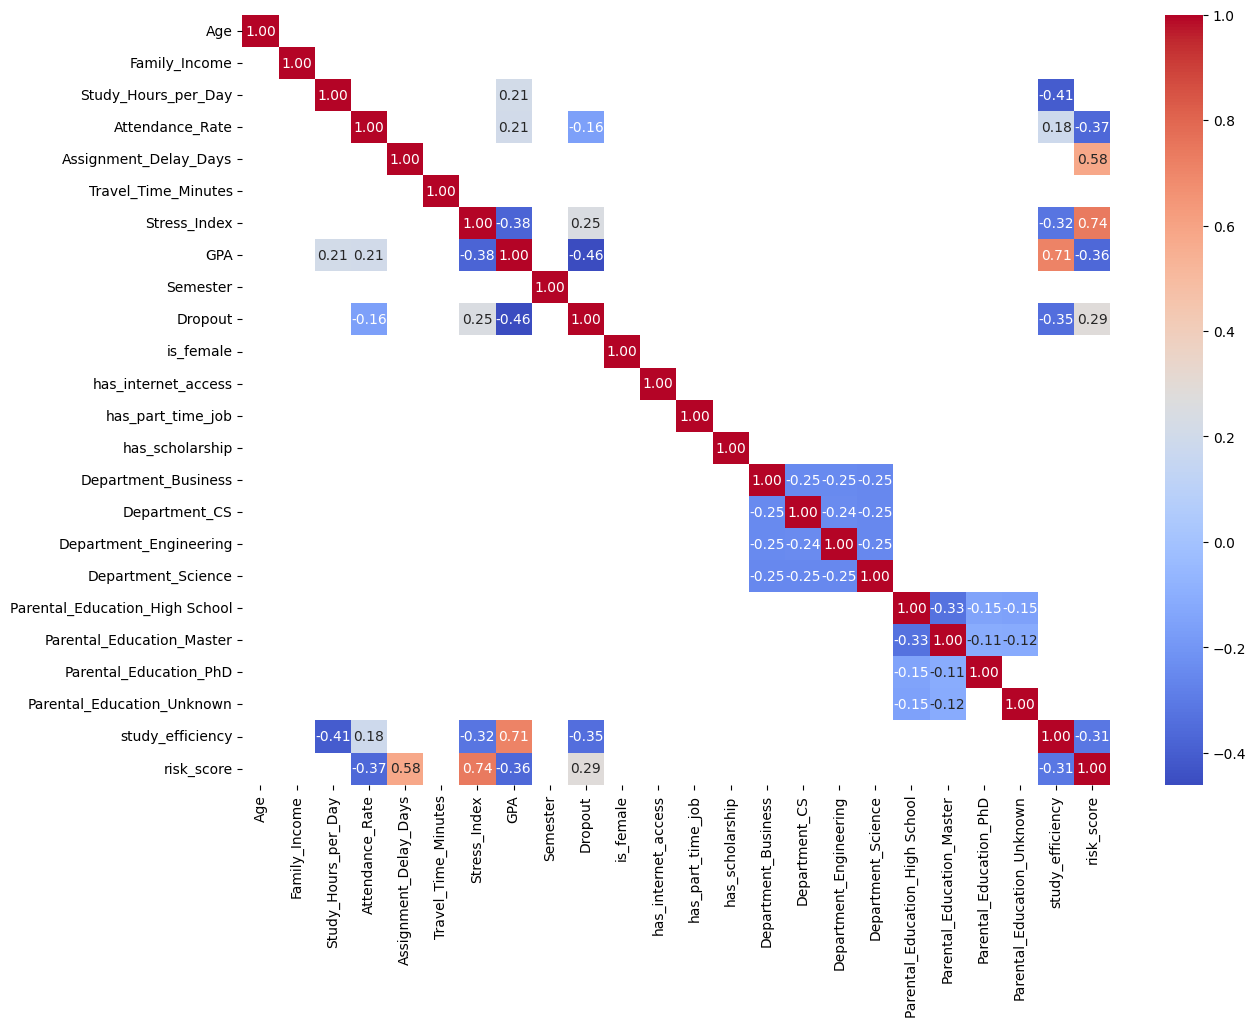

In [40]:
corr = df2.corr()
treshold = 0.1
mask = np.abs(corr) <=treshold
plt.figure(figsize=(14, 10))
sns.heatmap(df2.corr(numeric_only=True), annot=True, fmt='.2f',mask=mask, cmap='coolwarm')
plt.show()

### Train - Test split

80% antrenare - 20% testare

Folosim stratify=y pentru a garanta aceeasi proportie dropout/non-dropout.

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
 
print(f'\nTrain: {X_train.shape[0]} randuri')
print(f'Test: {X_test.shape[0]} randuri')
print(f'\nDistributie Dropout in train: {y_train.mean():.2%}')
print(f'Distributie Dropout in test:  {y_test.mean():.2%}')


Train: 8000 randuri
Test: 2000 randuri

Distributie Dropout in train: 23.54%
Distributie Dropout in test:  23.55%


### Scalarea datelor

Luam in calcul diferentele dintre GPA si Family_Income. GPA are valori cuprinse intre 0 si 4 pe cand in Family_Income sunt zeci de mii de valori.

Asadar, StandardScaler aduce toate coloanele la aceeasi scara pentru a evita problemele pe care algoritmul le-ar putea intampina la antrenare (o coloana mai importanta decat alta).

In [42]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
 
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)
 
print(f'\nScalare completa!')
print(f'GPA inainte: min={X_train["GPA"].min():.2f}, max={X_train["GPA"].max():.2f}')
print(f'GPA dupa: min={X_train_scaled["GPA"].min():.2f}, max={X_train_scaled["GPA"].max():.2f}')



Scalare completa!
GPA inainte: min=0.00, max=4.00
GPA dupa: min=-2.17, max=1.59


### Functie pentru evaluarea modelelor

In [43]:
def evalueaza_model(model, X_test, y_test, nume_model):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
 
    metrici = {
        'Model': nume_model,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    }
 
    print(f'\n{"="*55}')
    print(f'  {nume_model}')
    print(f'{"="*55}')
    for k, v in metrici.items():
        if k != 'Model':
            print(f'  {k:<12}: {v:.4f}  ({v*100:.2f}%)')
 
    print(f'\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['Non-Dropout', 'Dropout']))
 
    return metrici
 
 
def plot_confusion_matrix(model, X_test, y_test, title):
    # Confusion matrix — cum se citeste:
    #                   Prezis Non-Dropout | Prezis Dropout
    # Real Non-Dropout:  TN (corect)       | FP (fals pozitiv)
    # Real Dropout:      FN (ratat!)       | TP (corect)
    # FN = studenti care AU abandonat dar modelul i-a prezis ca ramanand
    cm = confusion_matrix(y_test, model.predict(X_test))
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Non-Dropout', 'Dropout'],
        yticklabels=['Non-Dropout', 'Dropout']
    )
    plt.title(f'Confusion Matrix — {title}')
    plt.ylabel('Valoare Reala')
    plt.xlabel('Valoare Prezisa')
    plt.tight_layout()
    plt.show()


### Model 1 - Logistic Regression

In [44]:
lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000        
)
lr_model.fit(X_train_scaled, y_train)
print('Logistic Regression antrenat!')

Logistic Regression antrenat!


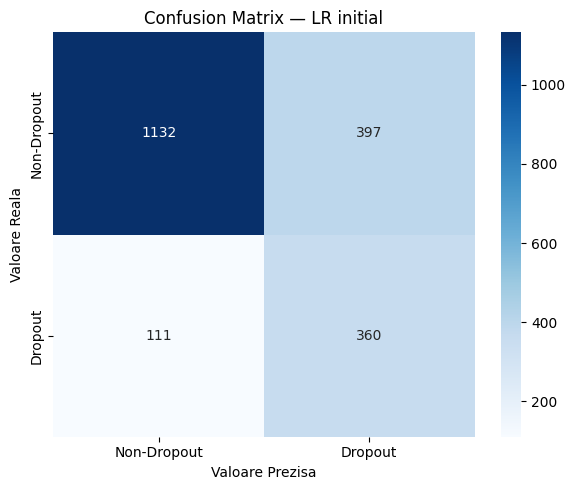

In [45]:
plot_confusion_matrix(lr_model, X_test_scaled, y_test, 'LR initial')

### Optimizare hiperparametrii - GridSearchCV

In [46]:
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}
 
# StratifiedKFold — pastreaza proportia dropout/non-dropout in fiecare fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
lr_grid = GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    param_grid=lr_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
 
lr_grid.fit(X_train_scaled, y_train)
 
print(f'\nCei mai buni hiperparametri: {lr_grid.best_params_}')
print(f'Cel mai bun F1 (cross-val):  {lr_grid.best_score_:.4f}')


Fitting 5 folds for each of 10 candidates, totalling 50 fits

Cei mai buni hiperparametri: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Cel mai bun F1 (cross-val):  0.5773


### Evaluare Logistic Regression


  Logistic Regression
  Accuracy    : 0.7420  (74.20%)
  Precision   : 0.4706  (47.06%)
  Recall      : 0.7643  (76.43%)
  F1-Score    : 0.5825  (58.25%)
  ROC-AUC     : 0.8198  (81.98%)

Classification Report:
              precision    recall  f1-score   support

 Non-Dropout       0.91      0.74      0.81      1529
     Dropout       0.47      0.76      0.58       471

    accuracy                           0.74      2000
   macro avg       0.69      0.75      0.70      2000
weighted avg       0.81      0.74      0.76      2000



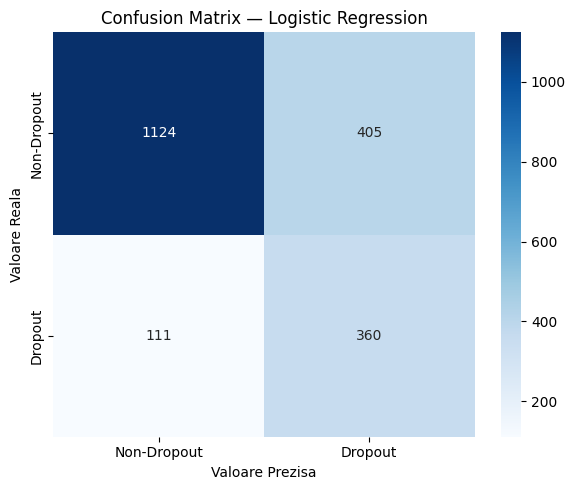

In [47]:
lr_best = lr_grid.best_estimator_
lr_metrici = evalueaza_model(lr_best, X_test_scaled, y_test, 'Logistic Regression')
plot_confusion_matrix(lr_best, X_test_scaled, y_test, 'Logistic Regression')


### Model 2 - Random Forest

Random Forest antrenat!


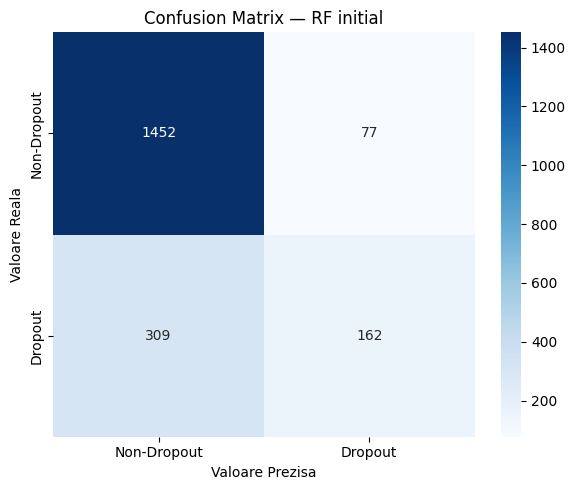

In [48]:
rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_estimators=100
)
rf_model.fit(X_train_scaled, y_train)
print('Random Forest antrenat!')
plot_confusion_matrix(rf_model, X_test_scaled, y_test, 'RF initial')

### Optimizare hiperparametri - GridSearchCV

In [49]:
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
 
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=rf_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
 
rf_grid.fit(X_train_scaled, y_train)
 
print(f'\nCei mai buni hiperparametri: {rf_grid.best_params_}')
print(f'Cel mai bun F1 (cross-val): {rf_grid.best_score_:.4f}')


Fitting 5 folds for each of 36 candidates, totalling 180 fits

Cei mai buni hiperparametri: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Cel mai bun F1 (cross-val): 0.5739


### Evaluare Random Forest


  Random Forest
  Accuracy    : 0.7790  (77.90%)
  Precision   : 0.5248  (52.48%)
  Recall      : 0.6518  (65.18%)
  F1-Score    : 0.5814  (58.14%)
  ROC-AUC     : 0.8123  (81.23%)

Classification Report:
              precision    recall  f1-score   support

 Non-Dropout       0.88      0.82      0.85      1529
     Dropout       0.52      0.65      0.58       471

    accuracy                           0.78      2000
   macro avg       0.70      0.73      0.72      2000
weighted avg       0.80      0.78      0.79      2000



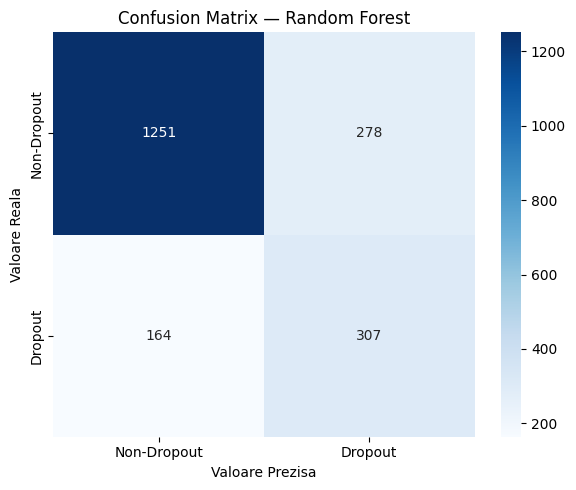

In [50]:
rf_best = rf_grid.best_estimator_
rf_metrici = evalueaza_model(rf_best, X_test_scaled, y_test, 'Random Forest')
plot_confusion_matrix(rf_best, X_test_scaled, y_test, 'Random Forest')


### Model 3 - XGBoost

scale_pos_weight: 3.25 (non-dropout / dropout)
XGBoost antrenat!


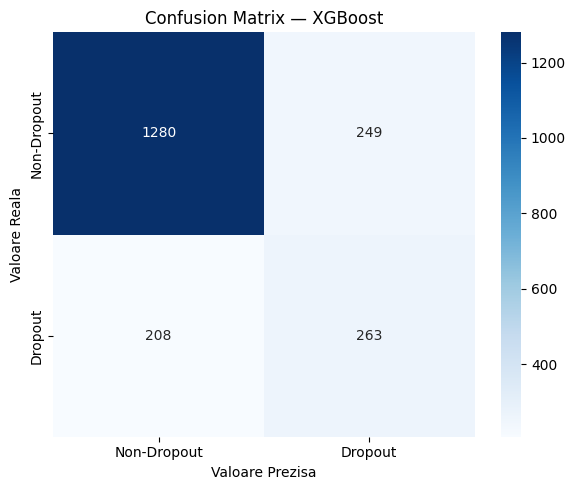

In [51]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f'scale_pos_weight: {scale_pos_weight:.2f} (non-dropout / dropout)')
 
xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_model.fit(X_train_scaled, y_train)
print('XGBoost antrenat!')
plot_confusion_matrix(xgb_model, X_test_scaled, y_test, 'XGBoost')


### Optimizare hiperparametri - GridSearchCV

In [52]:
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}
 
xgb_grid = GridSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    ),
    param_grid=xgb_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
 
xgb_grid.fit(X_train_scaled, y_train)
 
print(f'\nCei mai buni hiperparametri: {xgb_grid.best_params_}')
print(f'Cel mai bun F1 (cross-val): {xgb_grid.best_score_:.4f}')


Fitting 5 folds for each of 54 candidates, totalling 270 fits

Cei mai buni hiperparametri: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Cel mai bun F1 (cross-val): 0.5779


### Evaluare XGBoost


  XGBoost
  Accuracy    : 0.7405  (74.05%)
  Precision   : 0.4682  (46.82%)
  Recall      : 0.7495  (74.95%)
  F1-Score    : 0.5763  (57.63%)
  ROC-AUC     : 0.8126  (81.26%)

Classification Report:
              precision    recall  f1-score   support

 Non-Dropout       0.91      0.74      0.81      1529
     Dropout       0.47      0.75      0.58       471

    accuracy                           0.74      2000
   macro avg       0.69      0.74      0.69      2000
weighted avg       0.80      0.74      0.76      2000



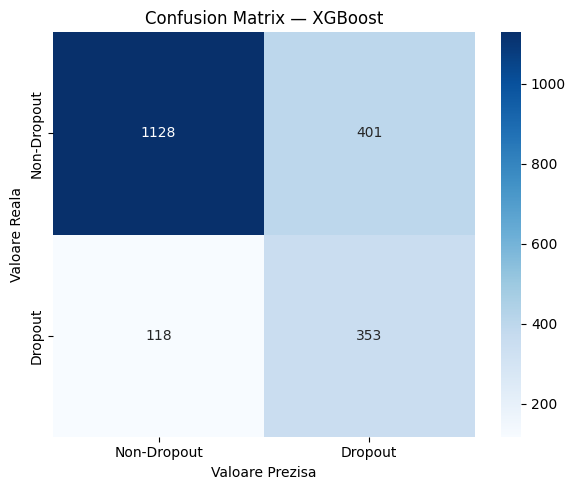

In [53]:
xgb_best = xgb_grid.best_estimator_
xgb_metrici = evalueaza_model(xgb_best, X_test_scaled, y_test, 'XGBoost')
plot_confusion_matrix(xgb_best, X_test_scaled, y_test, 'XGBoost')

In [54]:
rezultate = pd.DataFrame([lr_metrici, rf_metrici, xgb_metrici])
rezultate = rezultate.set_index('Model')
 
print('=== TABEL COMPARATIV MODELE ===')
print(rezultate.map(lambda x: f'{x*100:.2f}%').to_string())
 
print('\n=== MODELUL CEL MAI BUN PE FIECARE METRICA ===')
for col in rezultate.columns:
    best = rezultate[col].idxmax()
    val = rezultate[col].max()
    print(f'  {col:<12}: {best} ({val*100:.2f}%)')

=== TABEL COMPARATIV MODELE ===
                    Accuracy Precision  Recall F1-Score ROC-AUC
Model                                                          
Logistic Regression   74.20%    47.06%  76.43%   58.25%  81.98%
Random Forest         77.90%    52.48%  65.18%   58.14%  81.23%
XGBoost               74.05%    46.82%  74.95%   57.63%  81.26%

=== MODELUL CEL MAI BUN PE FIECARE METRICA ===
  Accuracy    : Random Forest (77.90%)
  Precision   : Random Forest (52.48%)
  Recall      : Logistic Regression (76.43%)
  F1-Score    : Logistic Regression (58.25%)
  ROC-AUC     : Logistic Regression (81.98%)


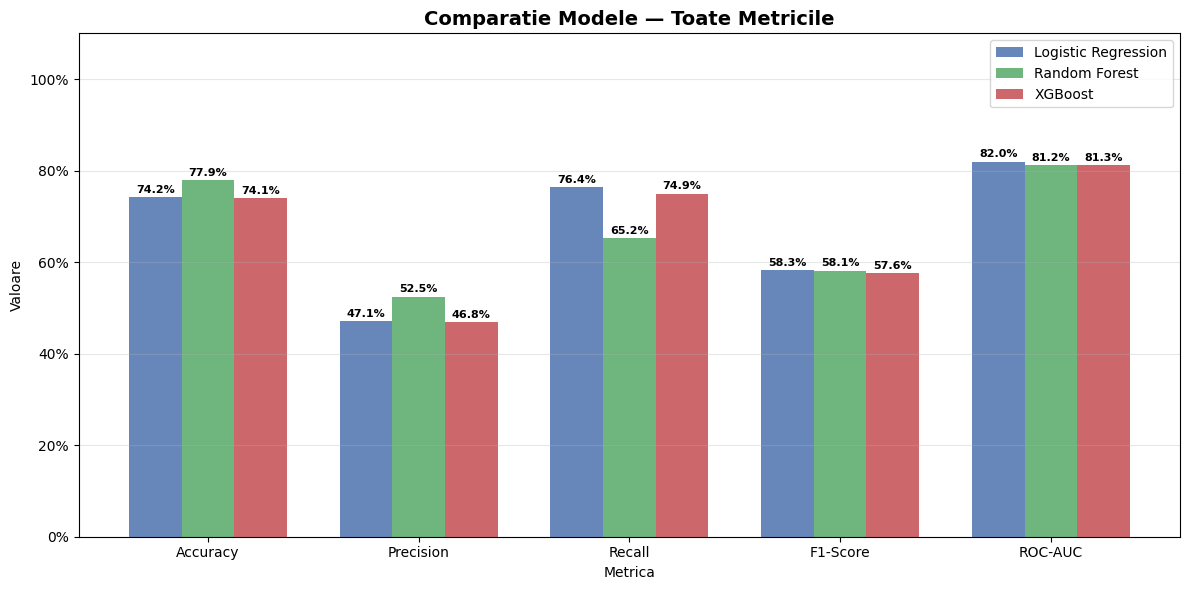

In [55]:
fig, ax = plt.subplots(figsize=(12, 6))
 
x = np.arange(len(rezultate.columns))
width = 0.25
culori = ['#4C72B0', '#55A868', '#C44E52']
 
for i, (model_name, row) in enumerate(rezultate.iterrows()):
    bars = ax.bar(x + i*width, row.values, width, label=model_name, color=culori[i], alpha=0.85)
    for bar, val in zip(bars, row.values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val*100:.1f}%',
            ha='center', va='bottom', fontsize=8, fontweight='bold'
        )
 
ax.set_xlabel('Metrica')
ax.set_ylabel('Valoare')
ax.set_title('Comparatie Modele — Toate Metricile', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(rezultate.columns)
ax.set_ylim(0, 1.1)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v*100:.0f}%'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparatie_modele.png', dpi=150, bbox_inches='tight')
plt.show()


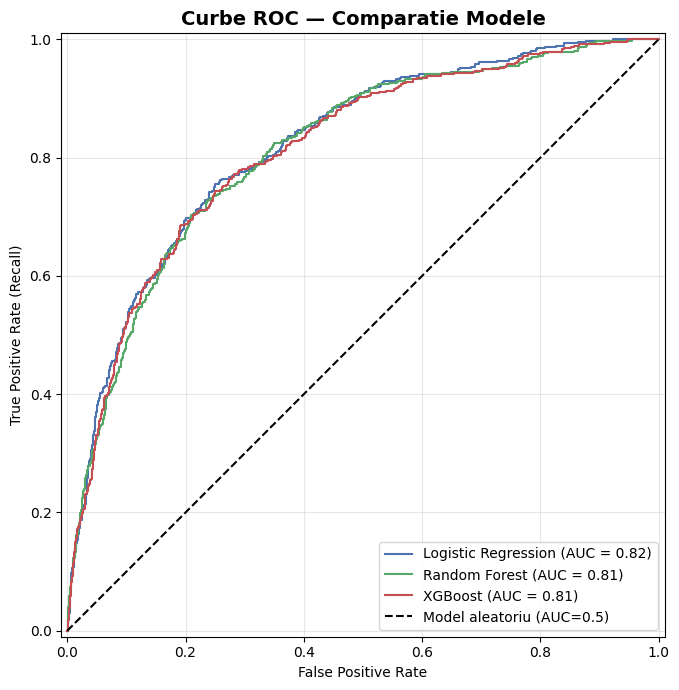

In [56]:
fig, ax = plt.subplots(figsize=(8, 7))
 
for model, name, culoare in [
    (lr_best, 'Logistic Regression', '#4C72B0'),
    (rf_best, 'Random Forest', '#55A868'),
    (xgb_best, 'XGBoost', '#C44E52')
]:
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, name=name, ax=ax, color=culoare)
 
ax.plot([0,1], [0,1], 'k--', label='Model aleatoriu (AUC=0.5)')
ax.set_title('Curbe ROC — Comparatie Modele', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


### Cross Validation final

In [57]:
print('=== Cross-Validation (5-fold, metric: F1) ===')
print(f'{"Model":<25} {"Media F1":>10} {"Std Dev":>10} {"Min":>8} {"Max":>8}')
print('-' * 65)
 
for model, name in [
    (lr_best, 'Logistic Regression'),
    (rf_best, 'Random Forest'),
    (xgb_best, 'XGBoost')
]:
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1', n_jobs=-1)
    print(f'{name:<25} {scores.mean()*100:>9.2f}%  {scores.std()*100:>9.2f}%  {scores.min()*100:>7.2f}%  {scores.max()*100:>7.2f}%')

=== Cross-Validation (5-fold, metric: F1) ===
Model                       Media F1    Std Dev      Min      Max
-----------------------------------------------------------------
Logistic Regression           57.73%       1.04%    56.01%    59.00%
Random Forest                 57.39%       1.47%    55.94%    59.70%
XGBoost                       57.79%       1.23%    56.10%    59.11%


In [58]:
print('\n=== REZULTATE FINALE ===')
print(rezultate.map(lambda x: f'{x*100:.2f}%'))
 
best_model_name = rezultate['F1-Score'].idxmax()
best_f1 = rezultate['F1-Score'].max()
best_auc = rezultate.loc[best_model_name, 'ROC-AUC']
 
print(f'\n>>> Modelul recomandat: {best_model_name}')
print(f'    F1-Score: {best_f1*100:.2f}%')
print(f'    ROC-AUC:  {best_auc*100:.2f}%')



=== REZULTATE FINALE ===
                    Accuracy Precision  Recall F1-Score ROC-AUC
Model                                                          
Logistic Regression   74.20%    47.06%  76.43%   58.25%  81.98%
Random Forest         77.90%    52.48%  65.18%   58.14%  81.23%
XGBoost               74.05%    46.82%  74.95%   57.63%  81.26%

>>> Modelul recomandat: Logistic Regression
    F1-Score: 58.25%
    ROC-AUC:  81.98%


## Analiza comparatie modele

* Accuracy - procentul de predictii corecte. Putin inselatoare in acest caz din cauza ca data set-ul este dezechilibrat.
* Precision - din toti studentii pe care modeulul i-a marcat ca fiind la risc, cati dintre ei chiar au abandonat.
* Recall - din toti studentii care chiar au abandonat, cati a reusit modelul sa detecteze. Pentru acest caz prefer sa alertez in plus decat sa ratez un student la risc.
* F1-Score - echilibrul dintre Precision si Recall.
* ROC-AUC - nota generala a modelului.

Cele 3 modele au performante foarte apropiate, ceea ce poate insemna ca exista limitari din date deoarece comportamentul uman e dificil de prezis si pe langa datele din data set pot exista si alte motive pentru care cineva abandoneaza.

### Modelul recomandat ar fi Logistic Regression
Deoarece:
* are cel mai bun ROC-AUC - separa cel mai bine dropout de non-dropout
* are cel mai bun recall - detecteaza cei mai multi studenti la risc

In practica, aplicat pe 1000 de studenti dintre care 400 abandoneaza, modelul detecteaza corect aproximativ 306 studenti la risc, deci rateaza 94 de studenti care abandoneaza si genereaza aproximativ 156 de alerte false pentru studentii care nu sunt la risc.

Cross-validation pe 5 fold-uri confirma ca rezultatele sunt stabile:
* Logistic Regression: 57.73% +- 1.04%
* Random Forest: 57.39% +- 1.47%
* XGBoost: 57.79% +- 1.23%

Deviatia standard este mica deci modelul ar performa asemanator pe date noi similare.


  Ensemble (Voting)
  Accuracy    : 0.7570  (75.70%)
  Precision   : 0.4893  (48.93%)
  Recall      : 0.7282  (72.82%)
  F1-Score    : 0.5853  (58.53%)
  ROC-AUC     : 0.8172  (81.72%)

Classification Report:
              precision    recall  f1-score   support

 Non-Dropout       0.90      0.77      0.83      1529
     Dropout       0.49      0.73      0.59       471

    accuracy                           0.76      2000
   macro avg       0.70      0.75      0.71      2000
weighted avg       0.80      0.76      0.77      2000



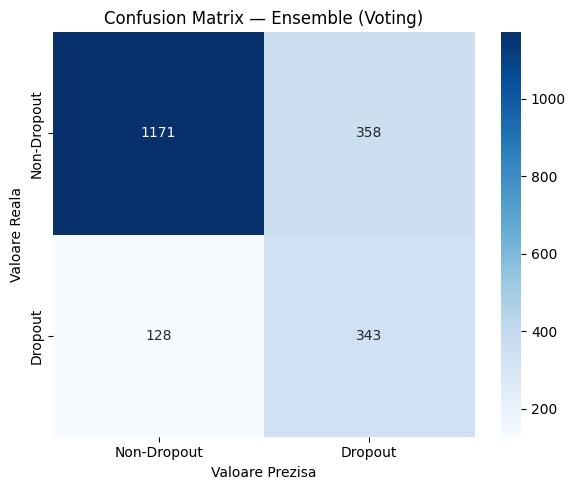

In [62]:
from sklearn.ensemble import VotingClassifier

# Combinam cele 3 modele optimizate anterior
ensemble = VotingClassifier(
    estimators=[
        ('lr',  lr_best),
        ('rf',  rf_best),
        ('xgb', xgb_best)
    ],
    voting='soft'  # foloseste probabilitatile fiecarui model, nu doar votul simplu
)

ensemble.fit(X_train_scaled, y_train)
ensemble_metrici = evalueaza_model(ensemble, X_test_scaled, y_test, 'Ensemble (Voting)')
plot_confusion_matrix(ensemble, X_test_scaled, y_test, 'Ensemble (Voting)')


  Ensemble LR + RF
  Accuracy    : 0.7670  (76.70%)
  Precision   : 0.5038  (50.38%)
  Recall      : 0.7113  (71.13%)
  F1-Score    : 0.5898  (58.98%)
  ROC-AUC     : 0.8182  (81.82%)

Classification Report:
              precision    recall  f1-score   support

 Non-Dropout       0.90      0.78      0.84      1529
     Dropout       0.50      0.71      0.59       471

    accuracy                           0.77      2000
   macro avg       0.70      0.75      0.71      2000
weighted avg       0.81      0.77      0.78      2000



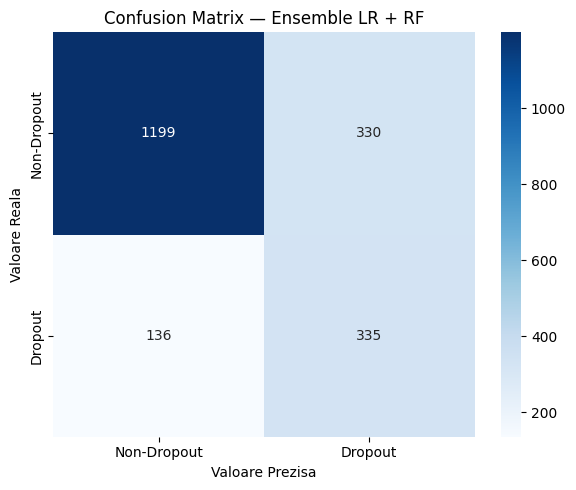

In [63]:
ensemble_lr_rf = VotingClassifier(
    estimators=[
        ('lr', lr_best),
        ('rf', rf_best)
    ],
    voting='soft'
)

ensemble_lr_rf.fit(X_train_scaled, y_train)
ensemble_lr_rf_metrici = evalueaza_model(ensemble_lr_rf, X_test_scaled, y_test, 'Ensemble LR + RF')
plot_confusion_matrix(ensemble_lr_rf, X_test_scaled, y_test, 'Ensemble LR + RF')

## CEL MAI BUN MODEL DE PANA ACUM